# Dependence and probability transformations

Specify a joint distribution, compare dependence models and examine the reference coordinates used in reliability analysis.

**Before you start:** the introductory tutorial and cumulative distribution functions.

## Problem and approach

A joint distribution combines **marginals** with a **copula**. A transformation then supplies coordinates for the reliability calculation without changing that joint law.

We will specify and sample joint laws, compare Gaussian Nataf and Rosenblatt, reproduce Lebrun and Dutfoy's conditioning-order example, and check generalized Student-t Nataf against an exact probability.

See the [theory](../theory.rst#theory-copulas) and [User guide](../copulas.rst). The reference papers are [generalized Nataf (2009)](https://doi.org/10.1016/j.probengmech.2008.05.001) and [Rosenblatt versus Nataf (2009)](https://doi.org/10.1016/j.probengmech.2009.04.006).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t, expon
from scipy.integrate import quad


import pystra as ra


## Specify marginals and dependence

The matrix below is the **latent** Gaussian correlation or Student-t shape matrix. It is generally not the physical Pearson correlation after applying the marginals. The existing `model.set_correlation(...)` interface retains its physical Pearson meaning and Gaussian Nataf calibration.

Holding the normal marginals and latent matrix fixed lets us see how changing the copula changes joint extremes. Identity Student-t shape would still not imply independence.

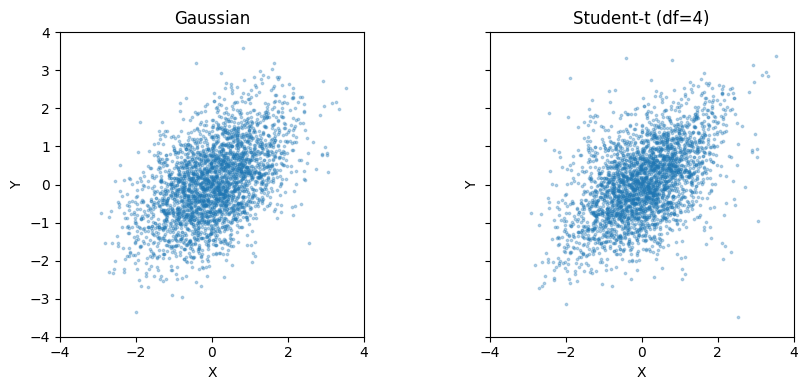

,"density at (1, 1)","CDF at (0, 0)"
Gaussian,0.094354,0.333333
Student-t (df=4),0.106205,0.333328


In [2]:
R = np.array([[1.0, 0.5], [0.5, 1.0]])
marginals = [ra.Normal("X", 0, 1), ra.Normal("Y", 0, 1)]
joints = {
    "Gaussian": ra.JointDistribution(marginals, ra.GaussianCopula(R)),
    "Student-t (df=4)": ra.JointDistribution(marginals, ra.StudentTCopula(R, df=4)),
}
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, (name, joint) in zip(axes, joints.items()):
    sample = joint.rvs(3000, seed=2026)
    ax.scatter(*sample.T, s=3, alpha=0.3)
    ax.set(title=name, xlabel="X", ylabel="Y", xlim=(-4, 4), ylim=(-4, 4))
    ax.set_aspect("equal")
fig.tight_layout()
plt.show()
pd.DataFrame(
    {
        name: {
            "density at (1, 1)": joint.pdf([1, 1]),
            "CDF at (0, 0)": joint.cdf([0, 0]),
        }
        for name, joint in joints.items()
    }
).T


**Figure.** Samples with identical normal marginals show different joint patterns for Gaussian, Student-t and Frank copulas; marginal distributions alone do not specify dependence.

## Transform and recover physical points

For a Gaussian copula, canonical Rosenblatt and Cholesky Nataf are the same mapping. `jacobian_u_wrt_x(u, x)` returns $\partial u/\partial x$, and `jacobian_x_wrt_u(u, x)` its inverse. Joint transformation methods take one vector; distribution methods accept rows of points. Copula-level Rosenblatt methods instead work on uniform coordinates.

In [3]:
joint = joints["Gaussian"]
nataf = joint.make_transformation("nataf")
rosenblatt = joint.make_transformation("rosenblatt")
x = np.array([1.2, -0.3])
u = nataf.x_to_u(x)
np.testing.assert_allclose(u, rosenblatt.x_to_u(x), atol=1e-12)
np.testing.assert_allclose(nataf.u_to_x(u), x, atol=1e-12)
J = nataf.jacobian_u_wrt_x(u, x)
np.testing.assert_allclose(joint.pdf(x), np.prod(norm.pdf(u)) * abs(np.linalg.det(J)))
print("Physical point:", x, "Normal point:", u)
print("du/dx:\n", J)


Physical point: [ 1.2 -0.3] Normal point: [ 1.2        -1.03923048]
du/dx:
 [[ 1.          0.        ]
 [-0.57735027  1.15470054]]


## Reproduce the conditioning-order benchmark

Lebrun and Dutfoy (2009, Section 6) use exponential marginals with rates 1 and 3 and failure event

$$g(X_1,X_2)=8X_1+2X_2-1\leq 0.$$

For a Frank copula with $\theta=10$, FORM gives approximately 0.107 in order $(X_1,X_2)$ and 0.122 in the reverse order. Exact probability is order-invariant; the first-order tangent approximation is not. The Gaussian copula with latent correlation 0.5 provides a comparison where orthogonal changes of normal coordinates preserve the optimum FORM result.

In [4]:
def exponential_model(copula):
    return ra.StochasticModel(
        ra.JointDistribution(
            [
                ra.ScipyDist("X1", expon(scale=1)),
                ra.ScipyDist("X2", expon(scale=1 / 3)),
            ],
            copula,
        )
    )


rows = []
for name, copula in [("Gaussian", ra.GaussianCopula(R)), ("Frank", ra.FrankCopula(10))]:
    choices = [("rosenblatt", [0, 1]), ("rosenblatt", [1, 0])]
    if name == "Gaussian":
        choices.insert(0, ("nataf", None))
    for method, order in choices:
        options = ra.FORMOptions(transform=method, rosenblatt_order=order)
        form = ra.FORM(
            model=exponential_model(copula),
            options=options,
            limit_state=ra.LimitState(lambda X1, X2: 8 * X1 + 2 * X2 - 1),
        )
        form_result = form.run()
        assert form_result.converged
        rows.append(
            {
                "Copula": name,
                "Method": method,
                "Order": str(order),
                "Beta": form_result.design_index,
                "FORM Pf": form_result.failure_probability,
            }
        )
results = pd.DataFrame(rows)
np.testing.assert_allclose(
    results.loc[results.Copula == "Frank", "FORM Pf"], [0.107, 0.122], atol=0.00015
)
results


,Copula,Method,Order,Beta,FORM Pf
0,Gaussian,nataf,None,1.295457,0.097581
1,Gaussian,rosenblatt,"[0, 1]",1.295457,0.097581
2,Gaussian,rosenblatt,"[1, 0]",1.295457,0.097581
3,Frank,rosenblatt,"[0, 1]",1.242811,0.106969
4,Frank,rosenblatt,"[1, 0]",1.165320,0.121945


We can integrate out $X_2$ using the Frank conditional CDF. This gives an independent numerical reference for the event probability:

$$P_f=\int_0^{1/8}e^{-x}\,F_{X_2\mid X_1=x}((1-8x)/2)\,dx.$$

The plotted differences are FORM approximation errors, not changes to the specified distribution.

Integrated Pf = 0.103839; quadrature error estimate = 5.6e-10


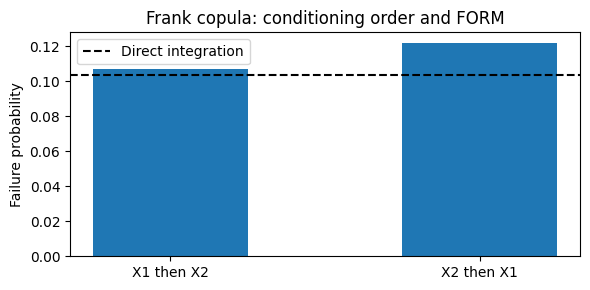

In [5]:
frank = ra.FrankCopula(10)


def integrand(x):
    p = [-np.expm1(-x), -np.expm1(-3 * (1 - 8 * x) / 2)]
    return np.exp(-x) * frank.rosenblatt(p)[1]


exact, quadrature_error = quad(integrand, 0, 1 / 8)
assert abs(exact - 0.1038) < 0.00005
print(
    f"Integrated Pf = {exact:.6f}; quadrature error estimate = {quadrature_error:.1e}"
)
fig, ax = plt.subplots(figsize=(6, 3))
frank_results = results[results.Copula == "Frank"]
ax.bar(["X1 then X2", "X2 then X1"], frank_results["FORM Pf"], width=0.5)
ax.axhline(exact, color="black", linestyle="--", label="Direct integration")
ax.set(ylabel="Failure probability", title="Frank copula: conditioning order and FORM")
ax.legend()
fig.tight_layout()
plt.show()


**Figure.** Frank-copula FORM probabilities change with conditioning order; the horizontal direct-integration reference represents the unchanged physical event.

## Generalized Student-t Nataf: an exact half-space check

Choose Student-t marginals matching the copula's degrees of freedom. The joint law is then multivariate Student-t. For $g=3-X-Y$ and unit marginal scales,

$$\beta=\frac{3}{\sqrt{2+2\rho}},\qquad P_f=T_4(-\beta).$$

Generalized Nataf makes this event affine in spherical Student-t coordinates, so its FORM result is exact up to solver tolerance. These coordinates have identity **shape**, not independent components or unit covariance. `get_equivalent_beta()` converts the resulting probability to the conventional normal index.

In [6]:
student_joint = ra.JointDistribution(
    [ra.ScipyDist("X", t(4)), ra.ScipyDist("Y", t(4))], ra.StudentTCopula(R, df=4)
)
options = ra.FORMOptions(transform="nataf")
form = ra.FORM(
    model=ra.StochasticModel(student_joint),
    options=options,
    limit_state=ra.LimitState(lambda X, Y: 3 - X - Y),
)
form_result = form.run()
beta_exact = 3 / np.sqrt(2 + 2 * R[0, 1])
pf_exact = t.sf(beta_exact, 4)
np.testing.assert_allclose(form_result.failure_probability, pf_exact, rtol=2e-6)
pd.Series(
    {
        "Geometric beta (Student-t space)": form_result.design_index,
        "Normal-equivalent beta": form_result.beta,
        "FORM Pf": form_result.failure_probability,
        "Exact Pf": pf_exact,
    }
)


Geometric beta (Student-t space)    1.732051
Normal-equivalent beta              1.410804
FORM Pf                             0.079151
Exact Pf                            0.079151
dtype: float64

## Choose the standard space for the analysis

An explicit Gaussian copula defaults to Nataf; Student-t and Frank default to normal Rosenblatt. System FORM, SORM, simulation methods and the strong maximum test currently require independent normal coordinates. Select Rosenblatt for these analyses with a non-Gaussian copula.

The following system has nested failure events, $X>3$ and $X>4$, so the series probability is exactly $P(X>3)$. This checks the shared transformation used by the component analyses.

In [7]:
normal_margin_student = ra.StochasticModel(joints["Student-t (df=4)"])
system = ra.SeriesSystem(
    [
        ra.Component("threshold_3", lambda X: 3 - X),
        ra.Component("threshold_4", lambda X: 4 - X),
    ]
)
system_form = ra.SystemFORM(normal_margin_student, system)
system_form_result = system_form.run()
np.testing.assert_allclose(system_form_result.failure_probability, norm.sf(3), rtol=1e-5)
print("Standard space:", system_form_result.component_results["threshold_3"].standard_space)
print("System Pf:", system_form_result.failure_probability)


Standard space: normal
System Pf: 0.0013498980316286287


Continuous marginals and positive-definite elliptical shape matrices are required. Frank is currently bivariate with $|\theta|\leq30$. Copula fitting and Pearson calibration for non-Gaussian copulas are not included. Finite precision limits extreme conditional probabilities; an unresolved transform raises rather than silently clipping coordinates.

For a practical component diagnostic, continue with the [strong maximum test tutorial](ex_strong_maximum.ipynb).

Continue with [Rosenblatt ordering in system reliability](ex_rosenblatt_system_order.ipynb) for a worked reproduction of Meinen and Steenbergen (2025), including transformation geometry, consistent component coordinates, and direct probability checks.

**Continue:** [User guide](../copulas.rst) · [API reference](../api/probability.rst) · [Theory](../theory/transformations.rst)